#### Best future price for non-fossil fuel energy

**Which non-fossil fuel energy technology will have the best price in the future?**

To be able to predict prices you'll probably need to use linear regression over the various non-fossil fuel options.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.dates import YearLocator, DateFormatter

In [11]:
# Import the original Levelized Cost of Energy data
# df_original_data = pd.read_csv('https://raw.githubusercontent.com/majavanput/co2-emissions/main/data/levelized-cost-of-energy.csv')
df_original_data = pd.read_csv('../data/levelized-cost-of-energy.csv')

In [24]:
# Print information about the DataFrame
df_original_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 926 entries, 0 to 925
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Entity                    926 non-null    str    
 1   Code                      926 non-null    str    
 2   Year                      926 non-null    int64  
 3   Bioenergy                 16 non-null     float64
 4   Geothermal                18 non-null     float64
 5   Offshore wind             26 non-null     float64
 6   Solar photovoltaic        302 non-null    float64
 7   Concentrated solar power  16 non-null     float64
 8   Hydropower                16 non-null     float64
 9   Onshore wind              890 non-null    float64
dtypes: float64(7), int64(1), str(2)
memory usage: 72.5 KB


In [26]:
# Overview of missing values per column
for name, values in df_original_data.items():
  print(f'Missing values in column {name}: ', df_original_data[name].isnull().sum())

# Total number of missing values in dataset
total_nan = df_original_data.isnull().sum().sum()
print(f"Total number of NaN values in the DataFrame: {total_nan}")

Missing values in column Entity:  0
Missing values in column Code:  0
Missing values in column Year:  0
Missing values in column Bioenergy:  910
Missing values in column Geothermal:  908
Missing values in column Offshore wind:  900
Missing values in column Solar photovoltaic:  624
Missing values in column Concentrated solar power:  910
Missing values in column Hydropower:  910
Missing values in column Onshore wind:  36
Total number of NaN values in the DataFrame: 5198


In [ ]:
df_cost_energy = df_original_data.copy()

# Drop unnecessary columns
df_cost_energy.drop(columns=['Code'], inplace=True)

In [25]:
df_cost_energy.head()

,Entity,Year,Bioenergy,Geothermal,Offshore wind,Solar photovoltaic,Concentrated solar power,Hydropower,Onshore wind
0,Argentina,1995,NaN,NaN,NaN,NaN,NaN,NaN,0.098309
1,Argentina,1997,NaN,NaN,NaN,NaN,NaN,NaN,0.050110
2,Argentina,2008,NaN,NaN,NaN,NaN,NaN,NaN,0.192745
3,Argentina,2009,NaN,NaN,NaN,NaN,NaN,NaN,0.108609
4,Argentina,2012,NaN,NaN,NaN,NaN,NaN,NaN,0.126297


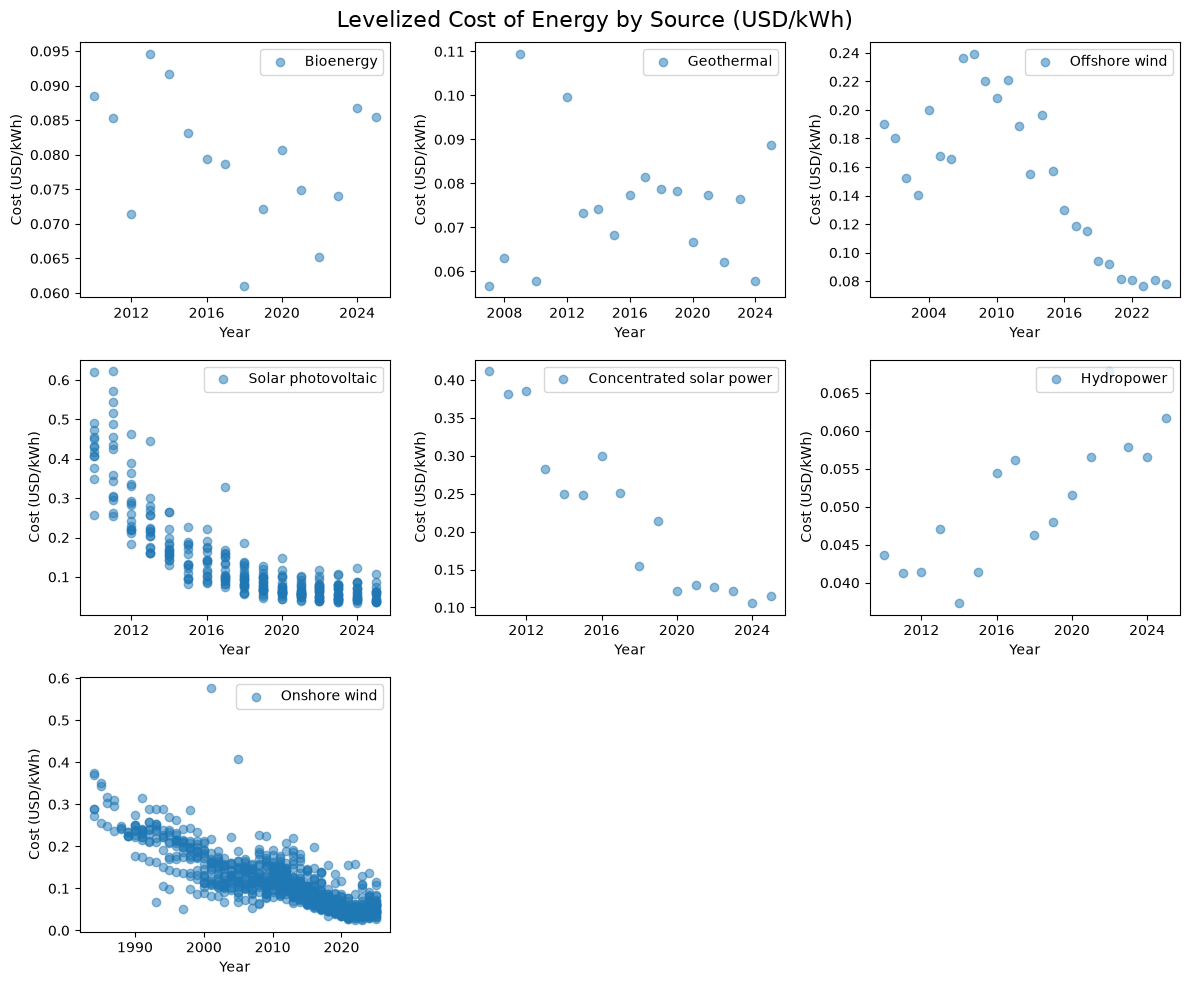

In [ ]:
df_cost_energy = df_original_data.copy()

energy_sources = [
    "Bioenergy",
    "Geothermal",
    "Offshore wind",
    "Solar photovoltaic",
    "Concentrated solar power",
    "Hydropower",
    "Onshore wind"
]

fig, ax = plt.subplots(3, 3, figsize=(12, 10))
ax = ax.flatten()

for i, source in enumerate(energy_sources):
    data = df_cost_energy[['Year', source]].dropna()

    x = data[['Year']]
    y = data[source]
    ax[i].scatter(x, y, alpha=0.5, label=source)
    ax[i].set_xlabel('Year')
    ax[i].set_ylabel('Cost (USD/kWh)')
    ax[i].legend(loc='upper right')

    # Use MaxNLocator to automatically determine tick spacing for integers, with a maximum of 5 ticks
    ax[i].xaxis.set_major_locator(plt.MaxNLocator(integer=True, nbins=5))

ax[8].set_visible(False)
ax[7].set_visible(False)
fig.suptitle('Levelized Cost of Energy by Source (USD/kWh)', fontsize=16)
plt.tight_layout()
plt.show()